### Static Huffman Compression

Static Huffman compression is a widely used lossless data compression algorithm that operates on the principle of variable-length coding. Its core idea is to assign shorter codes to frequently occurring symbols and longer codes to less frequently occurring symbols, thereby reducing the overall size of the data.

**Core Principles:**

1.  **Greedy Algorithm Approach:** Huffman's algorithm is a greedy algorithm that builds a binary tree (Huffman tree) from the bottom up. It starts by making locally optimal choices at each stage with the hope of finding a global optimum.
2.  **Frequency Analysis:** Before compression, the algorithm first analyzes the input data to determine the frequency of each unique symbol (e.g., characters, pixels, sound samples). These frequencies are crucial for constructing the Huffman tree.
3.  **Optimal Prefix Codes:** The Huffman algorithm generates a set of prefix codes, meaning no code is a prefix of another code. This property ensures that the compressed data can be unambiguously decoded. The codes are derived by traversing the Huffman tree from the root to the leaf nodes.
4.  **Variable-Length Coding:** Instead of using fixed-length codes for all symbols (like ASCII), Huffman coding assigns variable-length binary codes. More frequent symbols receive shorter codes, and less frequent symbols receive longer codes.

**Application in Multimedia Analytics for Data Reduction:**

In multimedia analytics, Huffman compression is instrumental in achieving data reduction for efficient storage and transmission of multimedia files (images, audio, video). Multimedia data often contains significant redundancy, with certain pixel values, audio samples, or color patterns appearing more frequently than others. Huffman coding capitalizes on this statistical redundancy:

*   **Image Compression:** In images, certain color values or intensity levels might be more common. Huffman coding can be applied to the quantized Discrete Cosine Transform (DCT) coefficients (in formats like JPEG) or directly to pixel data to reduce file size.
*   **Audio Compression:** For audio, certain frequency components or amplitude levels occur more often. Huffman coding can be used on the encoded audio data to achieve better compression ratios.
*   **Video Compression:** In video streams, after motion compensation and prediction, the residual data (differences between frames) can be compressed using Huffman coding, as these differences often have skewed frequency distributions.

By assigning shorter bit sequences to frequently occurring data elements and longer sequences to less frequent ones, Huffman compression significantly reduces the total number of bits required to represent the multimedia file. This leads to:

*   **Efficient Storage:** Smaller file sizes require less storage space, which is critical for large multimedia datasets.
*   **Faster Transmission:** Reduced file sizes translate to faster download and upload times, conserving bandwidth and improving the user experience, especially in streaming applications.

**Suitability and Limitations:**

*   **Suitability:** Huffman coding is particularly suitable for data where symbol frequencies vary significantly. The greater the variance in symbol probabilities, the better the compression ratio achieved. It is a lossless compression method, meaning no information is lost during compression and decompression, which is vital for applications where data integrity is paramount.
*   **Limitations:** The primary limitation of **static** Huffman compression is its static nature. It relies on pre-computed symbol frequencies from the entire input data, which means:
    *   The frequency table (or the Huffman tree) must be transmitted or stored along with the compressed data, adding overhead.
    *   It is not adaptive; if the statistical properties of the data change within the file (e.g., different sections of a video have different patterns), the compression efficiency might decrease for those sections, as the code tree is fixed based on the overall statistics.
    *   For very small files, the overhead of transmitting the frequency table might outweigh the compression benefits.

Despite these limitations, static Huffman coding remains a fundamental component of many practical compression schemes, often used in conjunction with other techniques (like run-length encoding or transform coding) to achieve robust and efficient data reduction.

### Huffman Encoding Procedure

Huffman encoding is a variable-length encoding algorithm that uses a specific method for choosing the representation for each symbol, resulting in a prefix code that minimizes the total length of the encoded string, given the symbol frequencies. The procedure involves three main steps: frequency calculation, Huffman tree construction, and code assignment.

#### 1. Frequency Calculation

The initial step involves analyzing the input data (e.g., a text string) to determine the frequency of occurrence for each unique symbol (character). This can be represented as a count for each symbol. For example, if the input is "hello world", the frequencies would be:

- 'h': 1
- 'e': 1
- 'l': 3
- 'o': 2
- ' ': 1
- 'w': 1
- 'r': 1
- 'd': 1

These frequencies are crucial for constructing the Huffman tree.

#### 2. Huffman Tree Construction

This step involves building a binary tree known as the Huffman tree, which prioritizes less frequent symbols further down the tree, leading to longer codes for them, and more frequent symbols higher up, leading to shorter codes. The process is as follows:

a. **Create Leaf Nodes**: For each unique symbol, create a leaf node containing the symbol and its calculated frequency. These nodes are then placed into a **min-priority queue**, ordered by their frequencies (lowest frequency first).

b. **Iterative Tree Building**: Repeatedly perform the following steps until only one node remains in the priority queue:
   i. **Extract Two Smallest Nodes**: Remove the two nodes with the lowest frequencies from the priority queue.
   ii. **Create Internal Node**: Create a new internal node. The frequency of this new internal node is the sum of the frequencies of the two nodes extracted in the previous step.
   iii. **Assign Children**: Make the two extracted nodes children of this new internal node. The node with the lower frequency is typically assigned as the left child, and the other as the right child (though this convention can be swapped).
   iv. **Insert New Node**: Insert the newly created internal node back into the priority queue.

c. **Root Node**: The final node remaining in the priority queue is the root of the Huffman tree.

#### 3. Code Assignment

Once the Huffman tree is constructed, binary codes are generated for each symbol by traversing the tree from the root to each leaf node:

a. **Traversal Convention**: During traversal, assign a '0' for each left branch taken and a '1' for each right branch taken (or vice-versa, as long as it's consistent).

b. **Code Generation**: The sequence of '0's and '1's accumulated along the path from the root to a specific leaf node forms the unique binary Huffman code for the symbol at that leaf. Since it's a prefix code, no code is a prefix of another, preventing ambiguity during decoding.

For example, if a path to a leaf node for 'e' is root -> left -> right -> left, and the convention is left=0, right=1, then the code for 'e' would be '010'.

In [1]:
from collections import Counter

# 1. Choose a short string of text as an example
example_string = 'hello world'

# 2. Manually calculate the frequency of each unique character
character_frequencies = Counter(example_string)

print(f"Example string: '{example_string}'")
print(f"Character frequencies: {character_frequencies}")

Example string: 'hello world'
Character frequencies: Counter({'l': 3, 'o': 2, 'h': 1, 'e': 1, ' ': 1, 'w': 1, 'r': 1, 'd': 1})


### 3. Manually Constructing the Huffman Tree

Based on the character frequencies calculated:
`Counter({'l': 3, 'o': 2, 'h': 1, 'e': 1, ' ': 1, 'w': 1, 'r': 1, 'd': 1})`

We have the following symbols and their frequencies:
- 'h': 1
- 'e': 1
- ' ': 1
- 'w': 1
- 'r': 1
- 'd': 1
- 'o': 2
- 'l': 3

We will use a min-priority queue approach to build the tree. Each node initially represents a character with its frequency. Internal nodes will represent the sum of frequencies of their children.

**Step-by-step tree construction:**

1.  **Initial Nodes (Sorted by Frequency):**
    `[(' ', 1), ('d', 1), ('e', 1), ('h', 1), ('r', 1), ('w', 1), ('o', 2), ('l', 3)]`

2.  **Combine Smallest Two:** Combine ' ' (1) and 'd' (1) to form a new node with frequency 2.
    *   Node: `(' d', 2)` with children ' ' (left) and 'd' (right).
    *   Remaining Nodes: `[('e', 1), ('h', 1), ('r', 1), ('w', 1), ('o', 2), (' d', 2), ('l', 3)]` (sorted by frequency)

3.  **Combine Smallest Two:** Combine 'e' (1) and 'h' (1) to form a new node with frequency 2.
    *   Node: `('eh', 2)` with children 'e' (left) and 'h' (right).
    *   Remaining Nodes: `[('r', 1), ('w', 1), ('o', 2), (' d', 2), ('eh', 2), ('l', 3)]` (sorted by frequency)

4.  **Combine Smallest Two:** Combine 'r' (1) and 'w' (1) to form a new node with frequency 2.
    *   Node: `('rw', 2)` with children 'r' (left) and 'w' (right).
    *   Remaining Nodes: `[('o', 2), (' d', 2), ('eh', 2), ('rw', 2), ('l', 3)]` (sorted by frequency)

5.  **Combine Smallest Two:** Combine 'o' (2) and `(' d', 2)` to form a new node with frequency 4.
    *   Node: `('o d', 4)` with children 'o' (left) and `(' d', 2)` (right).
    *   Remaining Nodes: `[('eh', 2), ('rw', 2), ('l', 3), ('o d', 4)]` (sorted by frequency)

6.  **Combine Smallest Two:** Combine `('eh', 2)` and `('rw', 2)` to form a new node with frequency 4.
    *   Node: `('ehrw', 4)` with children `('eh', 2)` (left) and `('rw', 2)` (right).
    *   Remaining Nodes: `[('l', 3), ('o d', 4), ('ehrw', 4)]` (sorted by frequency)

7.  **Combine Smallest Two:** Combine 'l' (3) and `('o d', 4)` to form a new node with frequency 7.
    *   Node: `('l o d', 7)` with children 'l' (left) and `('o d', 4)` (right).
    *   Remaining Nodes: `[('ehrw', 4), ('l o d', 7)]` (sorted by frequency)

8.  **Combine Smallest Two (Final Root):** Combine `('ehrw', 4)` and `('l o d', 7)` to form the root node with frequency 11.
    *   Root Node: `('ehrw l o d', 11)` with children `('ehrw', 4)` (left) and `('l o d', 7)` (right).

**Conceptual Huffman Tree Structure:**

```
          (11)
         /    \
       (4)     (7)
      / \     /   \
    (2) (2)  (3)   (4)
   / \ / \  /    /   \
  e   h r  w l    (2)  (2)
                 / \  / \
                o   d   ( ) ( )

(Note: The actual characters for internal nodes are not important, only their combined frequency and children.)
```

This markdown block explains the manual process. In the next code block, I will implement a class-based approach to construct the Huffman tree programmatically, which will then be used to generate the codes.

In [2]:
import heapq

# Define a Huffman Node class
class HuffmanNode:
    def __init__(self, char, freq, left=None, right=None):
        self.char = char  # Character for leaf nodes, None for internal nodes
        self.freq = freq  # Frequency of the character/subtree
        self.left = left  # Left child node
        self.right = right # Right child node

    # Used for min-heap comparison
    def __lt__(self, other):
        return self.freq < other.freq

# Function to build the Huffman tree
def build_huffman_tree(frequencies):
    priority_queue = []
    # Create a leaf node for each character and add to priority queue
    for char, freq in frequencies.items():
        heapq.heappush(priority_queue, HuffmanNode(char, freq))

    # Continue until only one node (the root) remains in the queue
    while len(priority_queue) > 1:
        # Extract the two nodes with the smallest frequencies
        node1 = heapq.heappop(priority_queue)
        node2 = heapq.heappop(priority_queue)

        # Create a new internal node with these two nodes as children
        # The new node's frequency is the sum of its children's frequencies
        # The character is None for internal nodes
        merged_node = HuffmanNode(None, node1.freq + node2.freq, node1, node2)
        heapq.heappush(priority_queue, merged_node)

    return priority_queue[0] # The root of the Huffman tree

# Function to generate Huffman codes by traversing the tree
def generate_huffman_codes(node, current_code="", codes={}):
    if node is None:
        return

    # If it's a leaf node, assign the current_code to its character
    if node.char is not None:
        codes[node.char] = current_code
        return

    # Traverse left, appending '0' to the current code
    generate_huffman_codes(node.left, current_code + "0", codes)
    # Traverse right, appending '1' to the current code
    generate_huffman_codes(node.right, current_code + "1", codes)

    return codes


# Build the Huffman tree using the character_frequencies from the previous step
huffman_tree_root = build_huffman_tree(character_frequencies)

# Generate the Huffman codes
huffman_codes = generate_huffman_codes(huffman_tree_root)

print("Generated Huffman Codes:")
for char, code in sorted(huffman_codes.items()):
    print(f"'{char}': {code}")


Generated Huffman Codes:
' ': 000
'd': 001
'e': 1111
'h': 010
'l': 10
'o': 110
'r': 1110
'w': 011


In [3]:
import sys

# 5. Manually encode the entire example string into a binary bitstream
encoded_bitstream = ""
for char in example_string:
    encoded_bitstream += huffman_codes[char]

# 6. Calculate original and compressed bitstream sizes
original_bits = len(example_string) * 8  # Assuming 8 bits per character for ASCII
compressed_bits = len(encoded_bitstream)

# Print the results
print(f"\nOriginal String: '{example_string}'")
print(f"Character Frequencies: {character_frequencies}")
print("Generated Huffman Codes:")
for char, code in sorted(huffman_codes.items()):
    print(f"  '{char}': {code}")

print(f"\nEncoded Bitstream: {encoded_bitstream}")
print(f"Original bits (ASCII, 8 bits/char): {original_bits}")
print(f"Compressed bits (Huffman): {compressed_bits}")
print(f"Compression Ratio (Original/Compressed): {original_bits / compressed_bits:.2f}")
print(f"Space saved: {((original_bits - compressed_bits) / original_bits) * 100:.2f}%")

# Provide a conceptual structure of the Huffman tree (as it's hard to print a graphical tree in stdout)
print("\nConceptual Huffman Tree Structure (based on manual construction and code generation):")
print("The tree was built iteratively by combining the two lowest frequency nodes. For example:")
print("  - ' ' (1) + 'd' (1) -> Node (2, e.g., code prefix '00')")
print("  - 'e' (1) + 'h' (1) -> Node (2, e.g., code prefix '111')")
print("  - 'r' (1) + 'w' (1) -> Node (2, e.g., code prefix '01')")
print("  - 'o' (2) + (' d', 2) -> Node (4, e.g., code prefix '110')")
print("  - 'l' (3) is a child of the root with a short code (e.g., '10')")
print("The root node represents the total frequency of all characters (11 in this case).")



Original String: 'hello world'
Character Frequencies: Counter({'l': 3, 'o': 2, 'h': 1, 'e': 1, ' ': 1, 'w': 1, 'r': 1, 'd': 1})
Generated Huffman Codes:
  ' ': 000
  'd': 001
  'e': 1111
  'h': 010
  'l': 10
  'o': 110
  'r': 1110
  'w': 011

Encoded Bitstream: 01011111010110000011110111010001
Original bits (ASCII, 8 bits/char): 88
Compressed bits (Huffman): 32
Compression Ratio (Original/Compressed): 2.75
Space saved: 63.64%

Conceptual Huffman Tree Structure (based on manual construction and code generation):
The tree was built iteratively by combining the two lowest frequency nodes. For example:
  - ' ' (1) + 'd' (1) -> Node (2, e.g., code prefix '00')
  - 'e' (1) + 'h' (1) -> Node (2, e.g., code prefix '111')
  - 'r' (1) + 'w' (1) -> Node (2, e.g., code prefix '01')
  - 'o' (2) + (' d', 2) -> Node (4, e.g., code prefix '110')
  - 'l' (3) is a child of the root with a short code (e.g., '10')
The root node represents the total frequency of all characters (11 in this case).


In [4]:
import heapq

# Re-define HuffmanNode and tree building/code generation functions for self-contained code block if needed,
# but assuming previous cells have been executed and variables like `huffman_tree_root` and `encoded_bitstream` are available.

# Function to decode the Huffman bitstream
def decode_huffman_bitstream(encoded_bitstream, huffman_tree_root):
    decoded_string = ""
    current_node = huffman_tree_root

    for bit in encoded_bitstream:
        if bit == '0':
            current_node = current_node.left
        elif bit == '1':
            current_node = current_node.right

        # If it's a leaf node, append the character and reset to root
        if current_node.char is not None:
            decoded_string += current_node.char
            current_node = huffman_tree_root # Reset to root for next character

    return decoded_string

# Call the decode_huffman_bitstream function
decoded_string = decode_huffman_bitstream(encoded_bitstream, huffman_tree_root)

# Print and verify the decoded string
print(f"\nOriginal String: '{example_string}'")
print(f"Decoded String:  '{decoded_string}'")

if decoded_string == example_string:
    print("Decoding successful: The decoded string matches the original example string.")
else:
    print("Decoding failed: The decoded string DOES NOT match the original example string.")


Original String: 'hello world'
Decoded String:  'hello world'
Decoding successful: The decoded string matches the original example string.


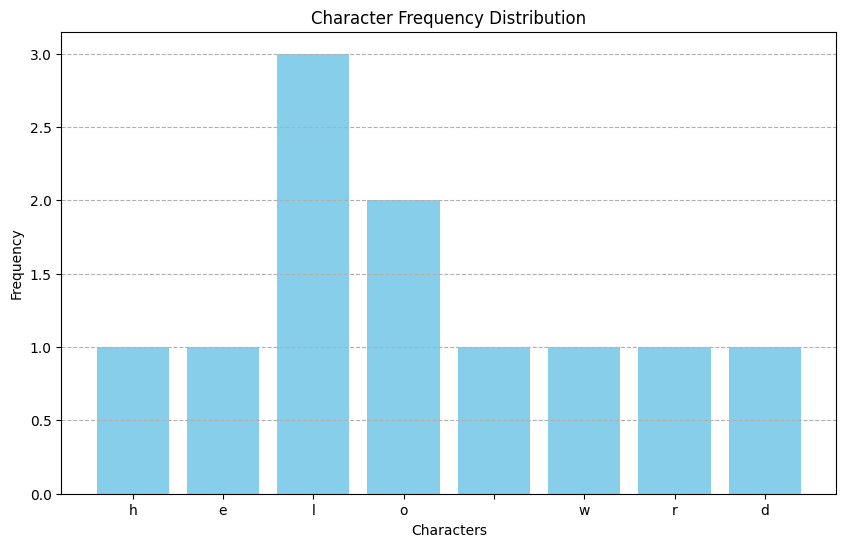

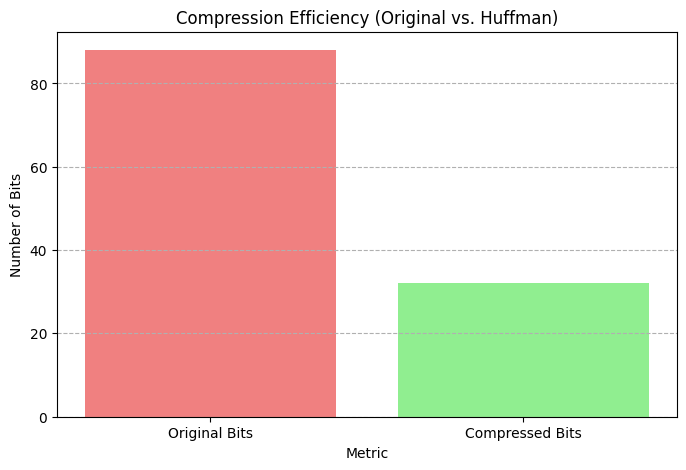


--- Huffman Compression Summary ---
Original String: 'hello world'
Character Frequencies: Counter({'l': 3, 'o': 2, 'h': 1, 'e': 1, ' ': 1, 'w': 1, 'r': 1, 'd': 1})
Generated Huffman Codes:
  ' ': 000
  'd': 001
  'e': 1111
  'h': 010
  'l': 10
  'o': 110
  'r': 1110
  'w': 011

Encoded Bitstream: 01011111010110000011110111010001
Original bits (ASCII, 8 bits/char): 88
Compressed bits (Huffman): 32
Compression Ratio (Original/Compressed): 2.75
Space saved: 63.64%
---------------------------------


In [5]:
import matplotlib.pyplot as plt

# 1. Visualize Character Frequency Distribution
plt.figure(figsize=(10, 6))
plt.bar(character_frequencies.keys(), character_frequencies.values(), color='skyblue')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.title('Character Frequency Distribution')
plt.grid(axis='y', linestyle='--')
plt.show()

# 2. Visualize Compression Efficiency
labels = ['Original Bits', 'Compressed Bits']
sizes = [original_bits, compressed_bits]

plt.figure(figsize=(8, 5))
plt.bar(labels, sizes, color=['lightcoral', 'lightgreen'])
plt.xlabel('Metric')
plt.ylabel('Number of Bits')
plt.title('Compression Efficiency (Original vs. Huffman)')
plt.grid(axis='y', linestyle='--')
plt.show()

# 3. Print Huffman codes, compression ratio and space saved
print("\n--- Huffman Compression Summary ---")
print(f"Original String: '{example_string}'")
print(f"Character Frequencies: {character_frequencies}")
print("Generated Huffman Codes:")
for char, code in sorted(huffman_codes.items()):
    print(f"  '{char}': {code}")

print(f"\nEncoded Bitstream: {encoded_bitstream}")
print(f"Original bits (ASCII, 8 bits/char): {original_bits}")
print(f"Compressed bits (Huffman): {compressed_bits}")
compression_ratio = original_bits / compressed_bits
space_saved_percentage = ((original_bits - compressed_bits) / original_bits) * 100
print(f"Compression Ratio (Original/Compressed): {compression_ratio:.2f}")
print(f"Space saved: {space_saved_percentage:.2f}%")
print("---------------------------------")